In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

training_testing_data = np.load('/Users/isaaclee/Wildfire_Research/training_testing_data_for_predicting_fire_area_from_ign_time_conditions.npy')
real_samples = np.load('/Users/isaaclee/Wildfire_Research/real_samples.npz')

In [21]:
print(training_testing_data.shape)
col_names = ["fire_area", "forecast_len", "u", "v", "humidity", "temp", "terrain_x", "terrain_y", "terrain_var", "terrain_RMS", "fuel1", "fuel2", "fuel3", "fuel4", "fuel5", "fuel6", "fuel7", "fuel8", "fuel9", "fuel10", "fuel11", "fuel12","fuel13", "fuel14"]
df = pd.DataFrame(training_testing_data, columns=col_names)
df.head()

(15200, 24)


,fire_area,forecast_len,u,v,humidity,temp,terrain_x,terrain_y,terrain_var,terrain_RMS,...,fuel5,fuel6,fuel7,fuel8,fuel9,fuel10,fuel11,fuel12,fuel13,fuel14
0,0.000170,0.027134,0.412048,0.448587,0.479408,0.642733,0.263365,0.550506,0.366568,0.469004,...,0.004469,0.000148,0.000027,0.164456,0.11235,0.621164,0.0,0.0,0.0,0.007027
1,0.002100,0.155214,0.412048,0.448587,0.479408,0.642733,0.263365,0.550506,0.366568,0.469004,...,0.004469,0.000148,0.000027,0.164456,0.11235,0.621164,0.0,0.0,0.0,0.007027
2,0.126972,0.687409,0.412048,0.448587,0.479408,0.642733,0.263365,0.550506,0.366568,0.469004,...,0.004469,0.000148,0.000027,0.164456,0.11235,0.621164,0.0,0.0,0.0,0.007027
3,0.101128,0.598904,0.412048,0.448587,0.479408,0.642733,0.263365,0.550506,0.366568,0.469004,...,0.004469,0.000148,0.000027,0.164456,0.11235,0.621164,0.0,0.0,0.0,0.007027
4,0.177548,0.909501,0.412048,0.448587,0.479408,0.642733,0.263365,0.550506,0.366568,0.469004,...,0.004469,0.000148,0.000027,0.164456,0.11235,0.621164,0.0,0.0,0.0,0.007027


In [22]:
X = df.drop('fire_area', axis=1)
y = df['fire_area']

print(df.shape)

# X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train = X[:-1200]
X_test = X[-1200:]
y_train = y[:-1200]
y_test = y[-1200:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
normalized_mae = mae / np.mean(y_test)

print("Mean Absolute Error: " + str(mae))
print("Normalized Mean Absolute Error: " + str(normalized_mae))

mape = np.mean(np.abs((y_test - y_pred) / y_test))
print("Mean Absolute Percent Error: " + str(mape))

(15200, 24)
Mean Absolute Error: 0.04515838909747266
Normalized Mean Absolute Error: 0.7103467198759932
Mean Absolute Percent Error: 15.068169636049896


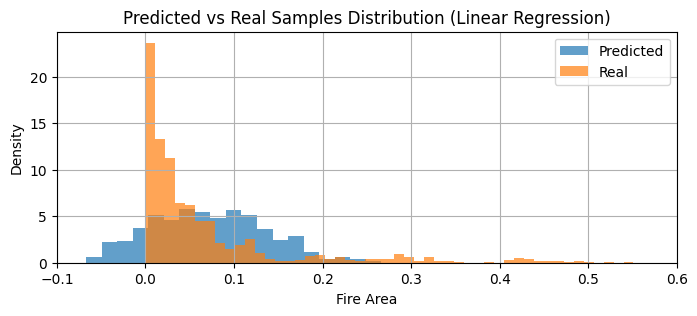

In [23]:
plt.figure(figsize=(8,3))
plt.title('Predicted vs Real Samples Distribution (Linear Regression)')
plt.hist(y_pred, bins='auto', alpha=0.7, label='Predicted', density=True)
plt.hist(y_test, bins='auto', alpha=0.7, label='Real', density=True)
plt.legend()
plt.xlabel('Fire Area')
plt.xlim((-0.1, 0.6))
plt.ylabel('Density')
plt.grid(True)
plt.show()